# UC Weak Counterfactual Explanation — Branch-and-Sandwich
## Structured Experiments Notebook

Three experiments across three IEEE benchmark grids:
- **Section 1** — Data loading and baseline UC solve
- **Section 2** — WCE with mutable line capacities (curtailment foil, 10%)
- **Section 3** — WCE with mutable min up/down times (curtailment foil, 10%)


## 0 · Imports and configuration

In [1]:
import os, importlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import replace
from typing import Optional, Callable, Dict, List, Tuple

import gurobipy as gp
from gurobipy import GRB

# ── Gurobi licence (adjust path to your machine) ──────────────────────────
os.environ["GRB_LICENSE_FILE"] = r"C:\Users\tomas\Desktop\gurobi.lic"
# os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"

# ── Project modules (reload on every run to pick up edits) ────────────────
import uc_pipeline, uc_master_relax_4b, uc_branch_sandwich_4b
import uc_data_loader

importlib.reload(uc_pipeline)
importlib.reload(uc_master_relax_4b)
importlib.reload(uc_branch_sandwich_4b)
importlib.reload(uc_data_loader)

from uc_pipeline import (
    NetworkUCData, IndexMap, Line, Generator,
    build_index_map_network_uc,
    build_cost_vector_network_uc,
    default_initial_conditions,
    solve_uc_with_cost_4b,
    make_curtailment_foil_4b,
)
from uc_branch_sandwich_4b import UCBranchAndSandwichWCE_4b
import uc_branch_sandwich_utdt
importlib.reload(uc_branch_sandwich_utdt)
from uc_branch_sandwich_utdt import UCBranchAndSandwichUTDT
from uc_master_relax_4b import (
    build_uc_relax_master_varfmax_4b,
    build_uc_operating_cost_expr_4b,
    remove_fixed_fmax_constraints_4b,
    add_variable_fmax_constraints_4b,
)
from uc_data_loader import quick_setup

warnings.filterwarnings("ignore")
print("Imports OK")


Imports OK


### Shared helpers (oracle, line-weight, plotting)

In [2]:
# ── Oracle ────────────────────────────────────────────────────────────────
def replace_line_limits(data: NetworkUCData, b_line: np.ndarray) -> NetworkUCData:
    """Return a copy of data with fmax replaced by b_line."""
    b_line = np.asarray(b_line, dtype=float).reshape(-1)
    new_lines = [replace(L, fmax=float(b_line[ell])) for ell, L in enumerate(data.lines)]
    return replace(data, lines=new_lines)


class UCWeakWCEOracle:
    """Caching oracle: solves plain and foil UC at a given b vector."""

    def __init__(self, data, cvec, idx, window_size, per_bus_neutrality,
                 u_init, p_init, on_t, off_t,
                 foil_extra_constr_fn=None, output_flag=0,
                 time_limit=None, cache_decimals=3):
        self.data = data
        self.cvec = np.asarray(cvec, float)
        self.idx  = idx
        self.window_size = int(window_size)
        self.per_bus_neutrality = bool(per_bus_neutrality)
        self.u_init, self.p_init = u_init, p_init
        self.on_t,   self.off_t  = on_t, off_t
        self.foil_extra_constr_fn = foil_extra_constr_fn
        self.output_flag  = int(output_flag)
        self.time_limit   = time_limit
        self.cache_decimals = int(cache_decimals)
        self.cache_plain  = {}
        self.cache_foil   = {}

    def _key(self, b): return tuple(np.round(np.asarray(b, float), self.cache_decimals))

    def _solve(self, b, extra_fn, cache):
        key = self._key(b)
        if key in cache: return cache[key]
        data_b = replace_line_limits(self.data, b)
        _, sol, z = solve_uc_with_cost_4b(
            data=data_b, idx=self.idx, cvec=self.cvec,
            window_size=self.window_size,
            per_bus_neutrality=self.per_bus_neutrality,
            u_init=self.u_init, p_init=self.p_init,
            on_time_init=self.on_t, off_time_init=self.off_t,
            extra_constr_fn=extra_fn,
            output_flag=self.output_flag, time_limit=self.time_limit,
        )
        out = (None, None, None) if sol is None else (float(sol["obj"]), np.array(z, float), sol)
        cache[key] = out
        return out

    def solve_plain(self, b): return self._solve(b, None,                       self.cache_plain)
    def solve_foil(self,  b): return self._solve(b, self.foil_extra_constr_fn,  self.cache_foil)


# ── Line-weight helper ────────────────────────────────────────────────────
def make_line_weights(DATA, b0, util=None, alpha=1.0, beta=1.0, gamma=0.5, eps_u=0.05):
    b_susc  = np.array([float(L.b) for L in DATA.lines])
    x_proxy = 1.0 / np.maximum(np.abs(b_susc), 1e-9)
    x_med   = np.median(x_proxy)
    b0_med  = np.median(b0)
    w = (x_proxy / max(x_med,1e-9))**alpha * (b0 / max(b0_med,1e-9))**beta
    if util is not None:
        w *= (1.0 / (eps_u + util))**gamma
    w = w / np.mean(w)
    return np.clip(w, 0.1, 10.0)


# ── Result plots ──────────────────────────────────────────────────────────
TECH_COLORS = {
    "Coal":"#73726c","CCGT":"#378ADD","OCGT":"#BA7517",
    "Nuclear":"#7F77DD","Hydro":"#1D9E75","Diesel":"#D85A30",
    "Biomass":"#639922","Wind":"#5DCAA5","Solar":"#EF9F27",
}

def plot_wce_results(DATA, idx, sol0, sol_hat, b0, b_hat,
                     res_bs, label="", free_idx=None):
    """
    Four-panel figure:
      (A) Dispatch stacked area — factual vs counterfactual
      (B) Curtailment per hour — factual vs counterfactual
      (C) Line flow utilisation heatmap at b_hat
      (D) B&S convergence: incumbent F and global_LB vs nodes
    """
    T   = int(DATA.T)
    nG  = len(DATA.gens)
    nL  = len(DATA.lines)
    hrs = np.arange(T)

    history = res_bs.get("history", [])

    fig = plt.figure(figsize=(16, 11))
    fig.suptitle(f"WCE results — {label}", fontsize=13, fontweight="bold", y=0.98)
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])

    # ── (A) Dispatch stacked area ─────────────────────────────────────────
    for ax, sol, title in [(ax1, sol0, "Factual dispatch"), (ax2, sol_hat, "Counterfactual dispatch")]:
        bottom = np.zeros(T)
        for g, gen in enumerate(DATA.gens):
            gtype = getattr(gen, "gtype", "Thermal")
            color = TECH_COLORS.get(gtype, "#888780")
            ax.fill_between(hrs, bottom, bottom + sol["p"][g],
                            label=f"G{g}", color=color, alpha=0.75, step="mid")
            bottom += sol["p"][g]
        # renewable injection
        if idx.curt.size > 0:
            ren_inj = np.array([
                float(DATA.rens[r].avail[t]) - sol["curt"][r, t]
                for t in range(T)
            ]).reshape(T) if len(DATA.rens)==1 else np.sum([
                np.array([float(DATA.rens[r].avail[t]) - sol["curt"][r, t] for t in range(T)])
                for r in range(len(DATA.rens))], axis=0)
            ax.fill_between(hrs, bottom, bottom + ren_inj,
                            color="#1D9E75", alpha=0.6, label="Renewable", step="mid")
            bottom += ren_inj
        ax.plot(hrs, DATA.demand.sum(axis=0), "k--", lw=1.5, label="Demand")
        ax.set_title(title, fontsize=10); ax.set_xlabel("Hour"); ax.set_ylabel("MW")
        ax.set_xlim(0, T-1); ax.grid(True, alpha=0.3)

    # ── (B) Curtailment per hour ──────────────────────────────────────────
    if idx.curt.size > 0:
        curt0   = sol0["curt"].sum(axis=0)
        curt_hat_h = sol_hat["curt"].sum(axis=0)
        ax3.bar(hrs - 0.2, curt0,     width=0.38, color="#D85A30", alpha=0.8, label="Factual")
        ax3.bar(hrs + 0.2, curt_hat_h, width=0.38, color="#378ADD", alpha=0.8, label="Counterfactual")
    ax3.set_title("Curtailment per hour (MWh)", fontsize=10)
    ax3.set_xlabel("Hour"); ax3.set_ylabel("MWh")
    ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis="y")

    # ── (C) Line flow utilisation heatmap ─────────────────────────────────
    if sol_hat is not None and "f" in sol_hat:
        flows  = np.abs(sol_hat["f"])           # (nL, T)
        limits = np.array([L.fmax for L in DATA.lines]).reshape(-1, 1)
        # Use b_hat limits for the relevant lines
        if b_hat is not None and free_idx is not None:
            limits_hat = limits.copy()
            for ell in free_idx:
                limits_hat[ell, 0] = max(float(b_hat[ell]), 1e-3)
            util_mat = flows / np.maximum(limits_hat, 1e-3)
        else:
            util_mat = flows / np.maximum(limits, 1e-3)
        util_mat = np.clip(util_mat, 0, 1)
        im = ax4.imshow(util_mat, aspect="auto", cmap="RdYlGn_r",
                        vmin=0, vmax=1, interpolation="nearest")
        ax4.set_title("Line flow utilisation at b̂ (green=low, red=high)", fontsize=10)
        ax4.set_xlabel("Hour"); ax4.set_ylabel("Line index")
        plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

    # ── (D) B&S convergence ───────────────────────────────────────────────
    # (gap evolution embedded in ax3 twin — we put convergence in a new figure)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

    # Separate convergence figure
    if history:
        fig2, (axF, axG) = plt.subplots(1, 2, figsize=(13, 4))
        fig2.suptitle(f"B&S convergence — {label}", fontsize=11, fontweight="bold")
        nodes = [h["nodes"] for h in history]
        Fs    = [h["best_F"] for h in history]
        gLBs  = [h["global_LB"] for h in history]
        gaps  = [h["gap_pct"] for h in history]

        axF.plot(nodes, Fs,   color="#D85A30", lw=2, label="Incumbent F")
        axF.plot(nodes, gLBs, color="#378ADD", lw=2, label="Global LB")
        axF.fill_between(nodes, gLBs, Fs, alpha=0.15, color="#888780")
        axF.set_xlabel("Nodes"); axF.set_ylabel("Objective (MW)")
        axF.set_title("Incumbent vs lower bound"); axF.legend(fontsize=9); axF.grid(True, alpha=0.3)

        axG.plot(nodes, gaps, color="#7F77DD", lw=2)
        axG.axhline(0, color="k", lw=0.8, ls="--")
        axG.set_xlabel("Nodes"); axG.set_ylabel("Gap (%)")
        axG.set_title("Optimality gap evolution"); axG.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


print("Helpers defined")


Helpers defined


---
## Section 1 · Data loading

Load the three benchmark grids from the generated JSON files.
Each call to `quick_setup` returns:
- `DATA` — `NetworkUCData` ready for the pipeline
- `idx`  — index map (variable block offsets)
- `cvec` — full cost vector
- `b0`   — baseline line capacities (fmax)
- initial conditions `u_init, p_init, on_t, off_t`


In [3]:
# ── 6-bus (Wood & Wollenberg) ─────────────────────────────────────────────
DATA_6, idx_6, cvec_6, b0_6, u_init_6, p_init_6, on_t_6, off_t_6 = quick_setup(
    "6bus_wood_wollenberg.json",
    carbon_price=50.0, curt_penalty=5.0, voll=20_000.0,
)


Loaded: 6bus_wood_wollenberg.json
  Buses: 6  |  Lines: 9  |  T: 24h
  Generators: 3  |  Renewables: 2
  System peak demand: 286.4 MW
  Total renewable capacity: 280.0 MW
  Carbon price: 50.0 $/tCO2


In [4]:
# ── IEEE 14-bus (enhanced) ────────────────────────────────────────────────
DATA_14, idx_14, cvec_14, b0_14, u_init_14, p_init_14, on_t_14, off_t_14 = quick_setup(
    "ieee14_enhanced.json",
    carbon_price=50.0, curt_penalty=5.0, voll=20_000.0,
)


Loaded: ieee14_enhanced.json
  Buses: 14  |  Lines: 20  |  T: 24h
  Generators: 6  |  Renewables: 2
  System peak demand: 1246.9 MW
  Total renewable capacity: 570.0 MW
  Carbon price: 50.0 $/tCO2


In [5]:
# ── IEEE 39-bus (New England) ─────────────────────────────────────────────
DATA_39, idx_39, cvec_39, b0_39, u_init_39, p_init_39, on_t_39, off_t_39 = quick_setup(
    "ieee39_newengland.json",
    carbon_price=50.0, curt_penalty=5.0, voll=20_000.0,
)


Loaded: ieee39_newengland.json
  Buses: 39  |  Lines: 46  |  T: 24h
  Generators: 10  |  Renewables: 4
  System peak demand: 2656.4 MW
  Total renewable capacity: 1900.0 MW
  Carbon price: 50.0 $/tCO2


### 1.1 · Baseline UC solve (factual)
Solve the plain UC at baseline `b0` for each grid.
This establishes the factual curtailment `C_0` used to set the 10% foil target.


In [6]:
ALPHA = 0.10   # 10% curtailment reduction required by foil

def run_baseline(DATA, idx, cvec, b0, u_init, p_init, on_t, off_t, label):
    """Solve plain UC at b0 and return (sol, C_0, curt_target)."""
    _, sol, _ = solve_uc_with_cost_4b(
        data=DATA, idx=idx, cvec=cvec,
        window_size=int(DATA.T), per_bus_neutrality=True,
        u_init=u_init, p_init=p_init,
        on_time_init=on_t, off_time_init=off_t,
        output_flag=0,
    )
    assert sol is not None, f"Factual solve failed for {label}"
    C_0 = float(np.sum(sol["curt"]))
    curt_target = (1.0 - ALPHA) * C_0
    print(f"[{label}]  C_0={C_0:.2f} MWh  |  "
          f"target (−{ALPHA*100:.0f}%)={curt_target:.2f} MWh  |  "
          f"already satisfied: {C_0 <= curt_target + 1e-3}")
    return sol, C_0, curt_target

sol0_6,  C0_6,  ct_6  = run_baseline(DATA_6,  idx_6,  cvec_6,  b0_6,  u_init_6,  p_init_6,  on_t_6,  off_t_6,  "6-bus")
sol0_14, C0_14, ct_14 = run_baseline(DATA_14, idx_14, cvec_14, b0_14, u_init_14, p_init_14, on_t_14, off_t_14, "14-bus")
sol0_39, C0_39, ct_39 = run_baseline(DATA_39, idx_39, cvec_39, b0_39, u_init_39, p_init_39, on_t_39, off_t_39, "39-bus")


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2653481
Academic license 2653481 - for non-commercial use only - registered to to___@ug.uchile.cl
[6-bus]  C_0=1289.65 MWh  |  target (−10%)=1160.68 MWh  |  already satisfied: False
[14-bus]  C_0=5255.33 MWh  |  target (−10%)=4729.80 MWh  |  already satisfied: False
[39-bus]  C_0=4745.28 MWh  |  target (−10%)=4270.75 MWh  |  already satisfied: False


In [7]:
# Define the Lagrangian violation expression for curtailment foil
def make_curtailment_violation_fn(alpha, C_factual):
    """
    Returns fn(m, var, idx) -> LinExpr  where the expression equals
    max(0, total_curt - target).  Since Gurobi needs a linear expression,
    we return total_curt - target (can be negative, but the Lagrangian
    penalty min drives it toward zero).
    """
    target = (1.0 - alpha) * C_factual
    def fn(m, var, idx):
        nR, T = idx.curt.shape
        total_curt = gp.quicksum(var["curt"][r, t]
                                 for r in range(nR) for t in range(T))
        # Return the raw excess — penalty drives this to ≤ 0
        return total_curt - target
    return fn


---
## Section 2 · WCE with mutable line capacities

For each grid we ask: *what is the minimum change to line capacities such that
the grid can achieve a 10% reduction in curtailment?*

The Branch-and-Sandwich algorithm searches over `b ∈ [b0, 5·b0]` for the free
lines (those with utilisation ≥ 75% in the factual solve) and minimises
`Σ w_ell · |b_ell − b0_ell|`.


### 2.1 · 6-bus grid

In [2]:
# ── Free lines: high utilisation in factual solution ─────────────────────
f_abs_max_6 = np.max(np.abs(sol0_6["f"]), axis=1)
util_6      = f_abs_max_6 / np.maximum(b0_6, 1e-9)

thr = 0.75
free_6 = [ell for ell in range(len(DATA_6.lines)) if util_6[ell] >= thr]
if not free_6:
    free_6 = list(np.argsort(-util_6)[:min(3, len(DATA_6.lines))])
print(f"Free lines (6-bus): {free_6}  utilisation: {util_6[free_6].round(3)}")

# ── Bounds: b can increase up to 5× but not decrease ─────────────────────
bL_6 = b0_6.copy()
bU_6 = b0_6.copy()
for ell in free_6:
    bU_6[ell] = 5.0 * b0_6[ell]

w_6 = make_line_weights(DATA_6, b0_6, util=util_6)


NameError: name 'np' is not defined

In [ ]:
# ── Foil: curtailment ≤ (1 − 0.10) × C_0 ────────────────────────────────
foil_6 = make_curtailment_foil_4b(DATA_6, alpha=ALPHA, C_factual=C0_6)

# ── Oracle ────────────────────────────────────────────────────────────────
oracle_6 = UCWeakWCEOracle(
    data=DATA_6, cvec=cvec_6, idx=idx_6,
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6, on_t=on_t_6, off_t=off_t_6,
    foil_extra_constr_fn=foil_6,
    output_flag=0,
)


In [ ]:
# ── B&S solver — 6-bus ────────────────────────────────────────────────────
bs_6 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_6,
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    foil_extra_constr_fn=foil_6,
    b0=b0_6,
    b_bounds=(bL_6, bU_6),
    b_free_idx=free_6,
    eps_b=1.0, eps_obj=1e-3, eps_weak=1e-3,
    max_nodes=300,
    w=w_6,
    verbose=True,
    foil_violation_expr_fn=make_curtailment_violation_fn(ALPHA, C0_6),
    lagrange_penalty=500.0,   # Lagrangian disabled for speed on small grid
)

res_6 = bs_6.run(
    window_size=int(DATA_6.T), per_bus_neutrality=True,
    u_init=u_init_6, p_init=p_init_6, on_t=on_t_6, off_t=off_t_6,
)

b_hat_6   = res_6["b_hat"]
F_opt_6   = res_6["F_opt"]
gap_pct_6 = (res_6["gap"] / max(abs(F_opt_6), 1e-9) * 100) if res_6["success"] else float("nan")
print(f"\n6-bus  |  F_opt={F_opt_6:.4f} MW  |  gap={gap_pct_6:.1f}%  |  nodes={res_6['nodes']}")


  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [INC] b_max: F=1410.6743 v=85824.831 v_D=85824.831
  [INNER_UB] tightened by incumbent: 85824.8306
[BS] node=0000 olb=0.0000 inner=[980.52,214823.10] bestF=1410.6743 gLB=0.0000 gap=100.0%
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [INC] node=0000: F=705.3372 v=85824.831 v_D=85824.831
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps
  [weak_ok] FAIL: v_D=216095.472430 > v=214823.095771 + eps


Baseline C_0=1289.65  |  b̂ curtailment=1158.12  |  target=1160.68  |  satisfied=True


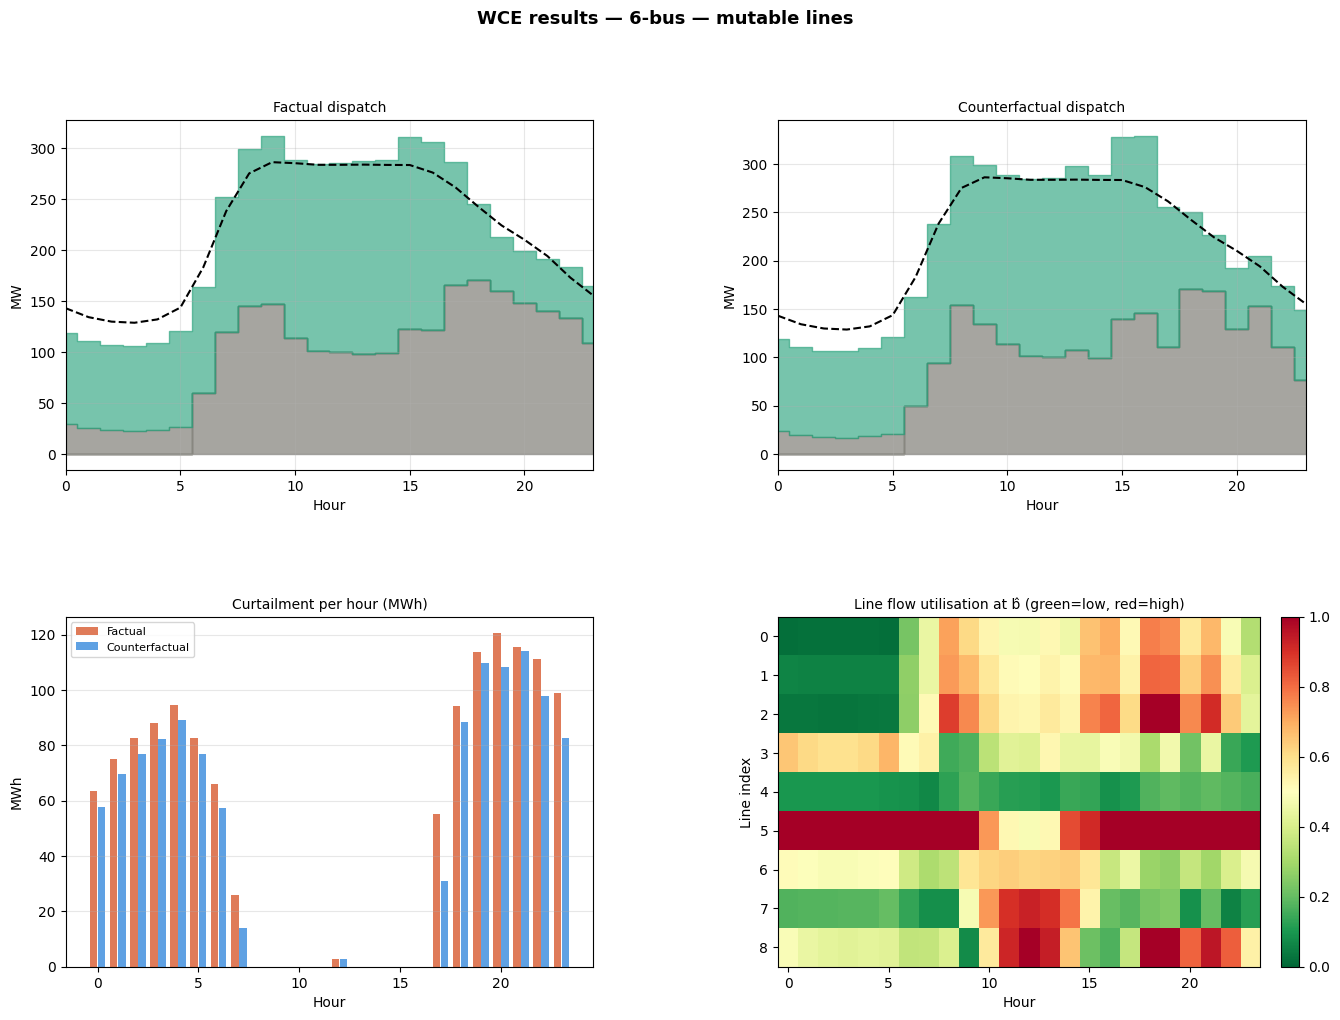

In [ ]:
# ── Verify and plot — 6-bus ───────────────────────────────────────────────
if res_6["success"]:
    v_hat_6, z_hat_6, sol_hat_6 = oracle_6.solve_plain(b_hat_6)
    assert sol_hat_6 is not None, "Plain solve at b_hat_6 failed"
    curt_hat_6 = float(np.sum(sol_hat_6["curt"]))
    print(f"Baseline C_0={C0_6:.2f}  |  b̂ curtailment={curt_hat_6:.2f}  |  "
          f"target={ct_6:.2f}  |  satisfied={curt_hat_6 <= ct_6 + 1e-3}")
    plot_wce_results(DATA_6, idx_6, sol0_6, sol_hat_6, b0_6, b_hat_6,
                     res_6, label="6-bus — mutable lines", free_idx=free_6)
else:
    print("No feasible WCE found for 6-bus grid.")


### 2.2 · IEEE 14-bus grid

In [ ]:
# ── Free lines ────────────────────────────────────────────────────────────
f_abs_max_14 = np.max(np.abs(sol0_14["f"]), axis=1)
util_14      = f_abs_max_14 / np.maximum(b0_14, 1e-9)
free_14 = [ell for ell in range(len(DATA_14.lines)) if util_14[ell] >= thr]
if not free_14:
    free_14 = list(np.argsort(-util_14)[:min(3, len(DATA_14.lines))])
print(f"Free lines (14-bus): {free_14}  utilisation: {util_14[free_14].round(3)}")

bL_14 = b0_14.copy(); bU_14 = b0_14.copy()
for ell in free_14: bU_14[ell] = 5.0 * b0_14[ell]
w_14 = make_line_weights(DATA_14, b0_14, util=util_14)


Free lines (14-bus): [0, 1, 2, 5, 6, 14, 15, 16, 18]  utilisation: [1.    0.764 1.    0.932 1.    1.    1.    1.    1.   ]


In [ ]:
foil_14  = make_curtailment_foil_4b(DATA_14, alpha=ALPHA, C_factual=C0_14)
oracle_14 = UCWeakWCEOracle(
    data=DATA_14, cvec=cvec_14, idx=idx_14,
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14, on_t=on_t_14, off_t=off_t_14,
    foil_extra_constr_fn=foil_14, output_flag=0,
)


In [ ]:
bs_14 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_14,
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    foil_extra_constr_fn=foil_14,
    b0=b0_14, b_bounds=(bL_14, bU_14), b_free_idx=free_14,
    eps_b=1.0, eps_obj=1e-3, eps_weak=1e-3,
    max_nodes=500, w=w_14, verbose=True,
    foil_violation_expr_fn=make_curtailment_violation_fn(ALPHA, C0_14),
    lagrange_penalty=300.0,
)

res_14 = bs_14.run(
    window_size=int(DATA_14.T), per_bus_neutrality=True,
    u_init=u_init_14, p_init=p_init_14, on_t=on_t_14, off_t=off_t_14,
)
b_hat_14 = res_14["b_hat"]
F_opt_14 = res_14["F_opt"]
gap_pct_14 = (res_14["gap"] / max(abs(F_opt_14),1e-9)*100) if res_14["success"] else float("nan")
print(f"\n14-bus  |  F_opt={F_opt_14:.4f} MW  |  gap={gap_pct_14:.1f}%  |  nodes={res_14['nodes']}")


  [weak_ok] FAIL: v_D=134887105.389740 > v=133740550.378273 + eps
  [INC] b_max: F=2192.2788 v=12797189.553 v_D=12797189.553
  [INNER_UB] tightened by incumbent: 12797189.5526
[BS] node=0000 olb=0.0000 inner=[3046.89,133740550.38] bestF=2192.2788 gLB=0.0000 gap=100.0%
  [weak_ok] FAIL: v_D=134887105.389740 > v=133740550.378273 + eps
  [INC] node=0000: F=1096.1394 v=17887001.558 v_D=17887001.558
  [weak_ok] FAIL: v_D=134887379.854495 > v=133391717.050515 + eps
  [weak_ok] FAIL: v_D=134887379.854495 > v=133391717.050515 + eps
  [weak_ok] FAIL: v_D=134887379.854495 > v=133391717.050515 + eps
  [weak_ok] FAIL: v_D=134887379.854495 > v=133391717.050515 + eps
  [weak_ok] FAIL: v_D=134887681.618988 > v=133740550.378273 + eps
  [weak_ok] FAIL: v_D=134887681.618988 > v=133740550.378273 + eps
  [weak_ok] FAIL: v_D=134887681.618988 > v=133740550.378273 + eps
  [weak_ok] FAIL: v_D=134887681.618988 > v=133740550.378273 + eps
  [weak_ok] FAIL: v_D=118350977.516401 > v=118339599.886924 + eps
  [weak_

Baseline C_0=5255.33  |  b̂ curtailment=4574.25  |  target=4729.80  |  satisfied=True


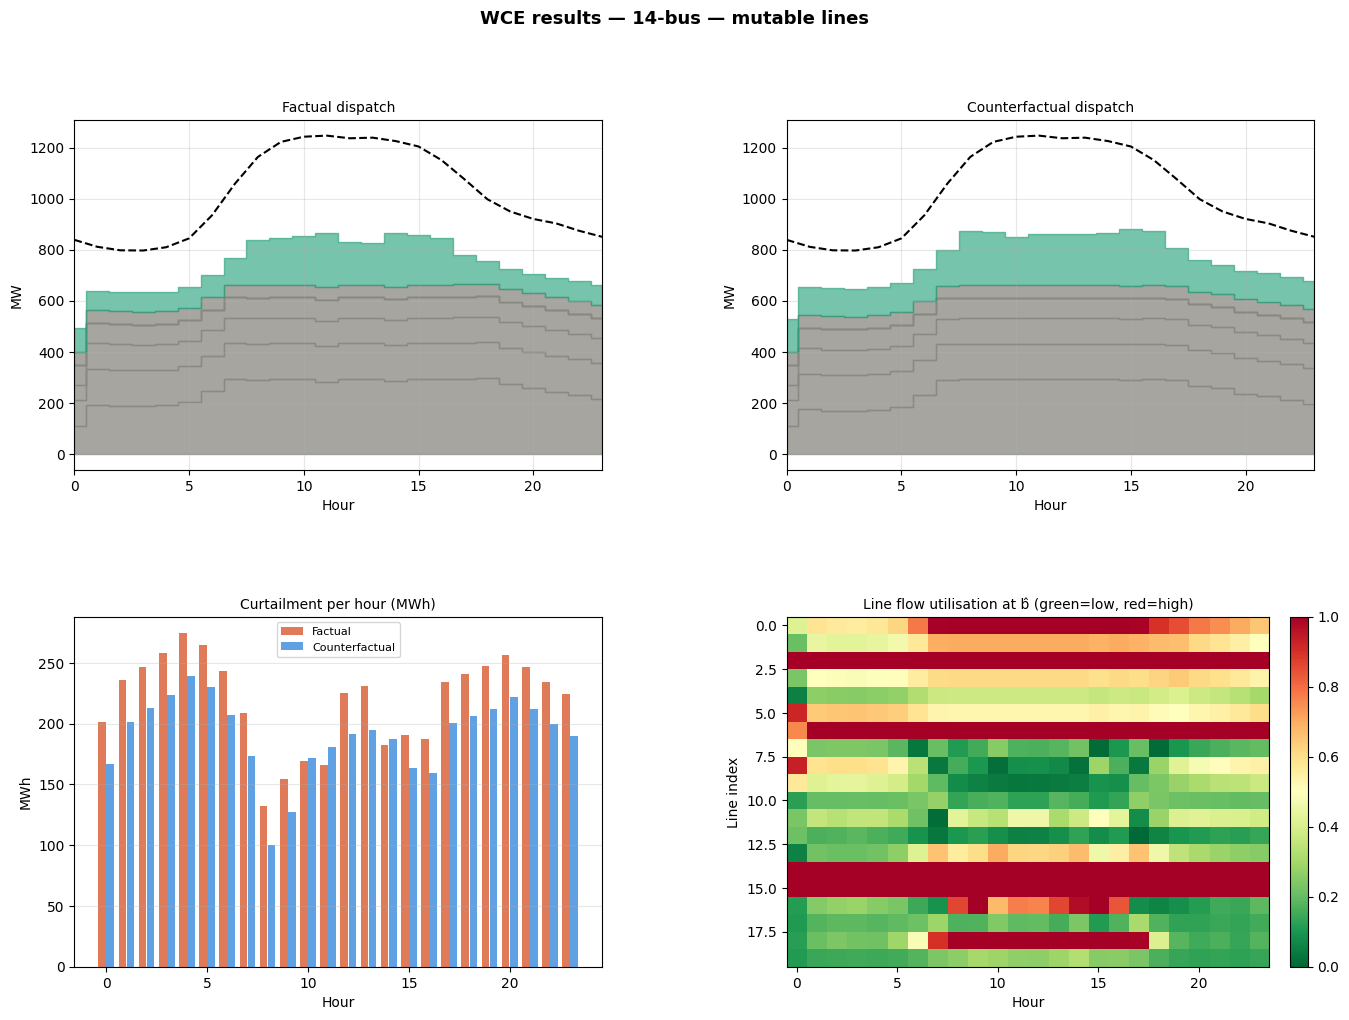

In [ ]:
if res_14["success"]:
    v_hat_14, z_hat_14, sol_hat_14 = oracle_14.solve_plain(b_hat_14)
    assert sol_hat_14 is not None, "Plain solve at b_hat_14 failed"
    curt_hat_14 = float(np.sum(sol_hat_14["curt"]))
    print(f"Baseline C_0={C0_14:.2f}  |  b̂ curtailment={curt_hat_14:.2f}  |  "
          f"target={ct_14:.2f}  |  satisfied={curt_hat_14 <= ct_14 + 1e-3}")
    plot_wce_results(DATA_14, idx_14, sol0_14, sol_hat_14, b0_14, b_hat_14,
                     res_14, label="14-bus — mutable lines", free_idx=free_14)
else:
    print("No feasible WCE found for 14-bus grid.")


### 2.3 · IEEE 39-bus grid

In [ ]:
f_abs_max_39 = np.max(np.abs(sol0_39["f"]), axis=1)
util_39      = f_abs_max_39 / np.maximum(b0_39, 1e-9)
free_39 = [ell for ell in range(len(DATA_39.lines)) if util_39[ell] >= thr]
if not free_39:
    free_39 = list(np.argsort(-util_39)[:min(5, len(DATA_39.lines))])
print(f"Free lines (39-bus): {free_39}  utilisation: {util_39[free_39].round(3)}")

bL_39 = b0_39.copy(); bU_39 = b0_39.copy()
for ell in free_39: bU_39[ell] = 5.0 * b0_39[ell]
w_39 = make_line_weights(DATA_39, b0_39, util=util_39)


Free lines (39-bus): [3, 6, 9, 13, 19, 30, 42, 44, 45]  utilisation: [0.833 1.    0.995 1.    1.    0.841 0.9   1.    1.   ]


In [ ]:
foil_39 = make_curtailment_foil_4b(DATA_39, alpha=ALPHA, C_factual=C0_39)
oracle_39 = UCWeakWCEOracle(
    data=DATA_39, cvec=cvec_39, idx=idx_39,
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39, on_t=on_t_39, off_t=off_t_39,
    foil_extra_constr_fn=foil_39, output_flag=0,
)


In [ ]:
bs_39 = UCBranchAndSandwichWCE_4b(
    oracle=oracle_39,
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    foil_extra_constr_fn=foil_39,
    b0=b0_39, b_bounds=(bL_39, bU_39), b_free_idx=free_39,
    eps_b=2.0, eps_obj=1e-3, eps_weak=1e-3,
    max_nodes=800, w=w_39, verbose=True,
    foil_violation_expr_fn=make_curtailment_violation_fn(ALPHA, C0_39),
    lagrange_penalty=300.0,
)

res_39 = bs_39.run(
    window_size=int(DATA_39.T), per_bus_neutrality=True,
    u_init=u_init_39, p_init=p_init_39, on_t=on_t_39, off_t=off_t_39,
)
b_hat_39 = res_39["b_hat"]
F_opt_39 = res_39["F_opt"]
gap_pct_39 = (res_39["gap"] / max(abs(F_opt_39),1e-9)*100) if res_39["success"] else float("nan")
print(f"\n39-bus  |  F_opt={F_opt_39:.4f} MW  |  gap={gap_pct_39:.1f}%  |  nodes={res_39['nodes']}")


  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [INC] b_max: F=4990.6683 v=70429.444 v_D=70429.444
  [INNER_UB] tightened by incumbent: 70429.4437
[BS] node=0000 olb=0.0000 inner=[2604.48,142840.59] bestF=4990.6683 gLB=0.0000 gap=100.0%
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [INC] node=0000: F=2495.3341 v=70429.444 v_D=70429.444
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [INC] node=0000: F=19.2000 v=136972.098 v_D=136972.098
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794587.333667 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=2794539.199760 > v=142840.591030 + eps
  [weak_ok] FAIL: v_D=27

Baseline C_0=4745.28  |  b̂ curtailment=4207.46  |  target=4270.75  |  satisfied=True


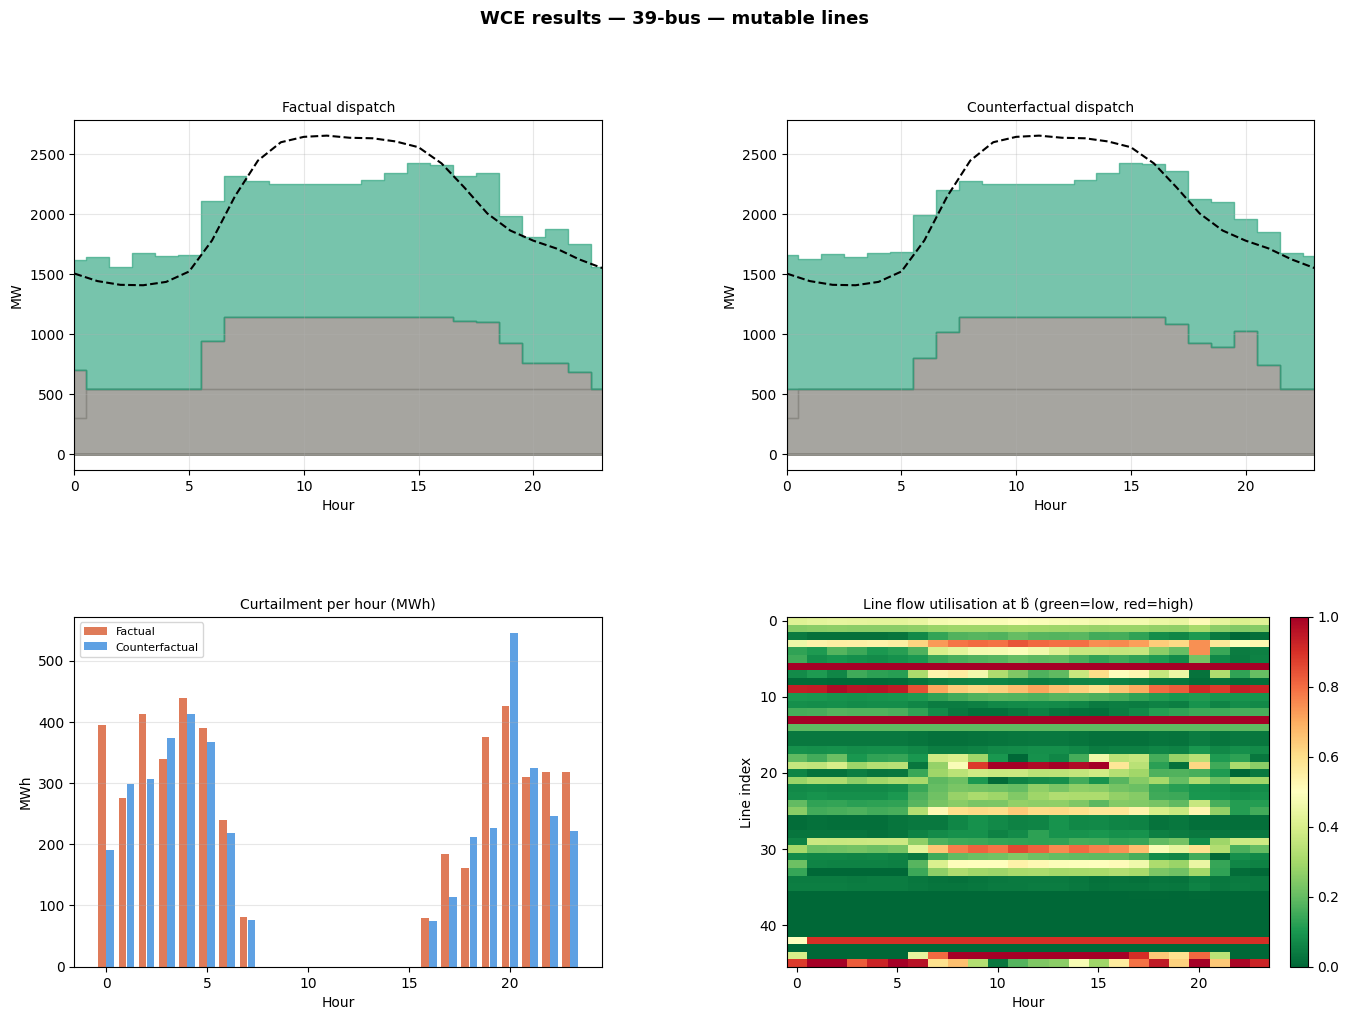

In [ ]:
if res_39["success"]:
    v_hat_39, z_hat_39, sol_hat_39 = oracle_39.solve_plain(b_hat_39)
    assert sol_hat_39 is not None, "Plain solve at b_hat_39 failed"
    curt_hat_39 = float(np.sum(sol_hat_39["curt"]))
    print(f"Baseline C_0={C0_39:.2f}  |  b̂ curtailment={curt_hat_39:.2f}  |  "
          f"target={ct_39:.2f}  |  satisfied={curt_hat_39 <= ct_39 + 1e-3}")
    plot_wce_results(DATA_39, idx_39, sol0_39, sol_hat_39, b0_39, b_hat_39,
                     res_39, label="39-bus — mutable lines", free_idx=free_39)
else:
    print("No feasible WCE found for 39-bus grid.")


### 2.4 · Cross-grid comparison

In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────
print(f"{'Grid':<10} {'C_0 (MWh)':>12} {'F_opt (MW)':>12} {'Gap (%)':>10} {'Nodes':>8}")
print("-" * 55)
for lbl, C0, res in [
    ("6-bus",  C0_6,  res_6),
    ("14-bus", C0_14, res_14),
    ("39-bus", C0_39, res_39),
]:
    F = res.get("F_opt", float("nan"))
    g = (res["gap"] / max(abs(F),1e-9)*100) if res["success"] else float("nan")
    print(f"{lbl:<10} {C0:>12.2f} {F:>12.4f} {g:>10.1f} {res['nodes']:>8}")


Grid          C_0 (MWh)   F_opt (MW)    Gap (%)    Nodes
-------------------------------------------------------
6-bus           1289.65       0.5086        0.0      122
14-bus          5255.33       3.1180       82.7      500
39-bus          4745.28       0.6825        0.0      295


---
## Section 3 · WCE with mutable min up/down times

Here we ask: *what is the minimum relaxation of generator commitment
flexibility (UT/DT) such that the grid can achieve a 10% curtailment reduction?*

**Formulation:**
- Decision variables: `UT_g ∈ {1, …, UT_g^orig}` and `DT_g ∈ {1, …, DT_g^orig}` for each free generator
- Free generators: only those with `UT_orig > 1` or `DT_orig > 1`
- Objective: minimise `Σ_g [(UT_g^orig − UT_g) + (DT_g^orig − DT_g)]` (total flexibility gained)
- Foil: same 10% curtailment reduction as Section 2

**Algorithm:** Discrete Branch-and-Bound over the UT/DT space.
Each candidate `(UT, DT)` configuration is evaluated by solving the full
integer UC — no relaxation is needed since the search space is finite and small.


### 3.0 · UT/DT WCE infrastructure

In [8]:
import importlib, uc_branch_sandwich_utdt
importlib.reload(uc_branch_sandwich_utdt)
from uc_branch_sandwich_utdt import UCBranchAndSandwichUTDT
PER_BUS_NEUTRALITY = True
WINDOW_SIZE = 24

In [9]:
# ── UT/DT B&S solver ─────────────────────────────────────────────────────
import importlib, uc_branch_sandwich_utdt
importlib.reload(uc_branch_sandwich_utdt)
from uc_branch_sandwich_utdt import UCBranchAndSandwichUTDT

def get_free_generators(gens):
    """Generators with UT > 1 or DT > 1."""
    return [g for g, gen in enumerate(gens) if int(gen.UT) > 1 or int(gen.DT) > 1]

print("UCBranchAndSandwichUTDT ready")


UCBranchAndSandwichUTDT ready


In [10]:
# ── UT/DT B&S solver ─────────────────────────────────────────────────────
import importlib, uc_branch_sandwich_utdt
importlib.reload(uc_branch_sandwich_utdt)
from uc_branch_sandwich_utdt import UCBranchAndSandwichUTDT

def get_free_generators(gens):
    """Generators with UT > 1 or DT > 1."""
    return [g for g, gen in enumerate(gens) if int(gen.UT) > 1 or int(gen.DT) > 1]

print("UCBranchAndSandwichUTDT ready")


UCBranchAndSandwichUTDT ready


### 3.1 · 6-bus — mutable UT/DT

In [11]:
# ── Free generators (UT/DT > 1) ───────────────────────────────────────────
free_gens_6  = get_free_generators(DATA_6.gens)
ut_orig_6    = np.array([int(g.UT) for g in DATA_6.gens])
dt_orig_6    = np.array([int(g.DT) for g in DATA_6.gens])
print(f"Free generators (6-bus): {free_gens_6}")
for g in free_gens_6:
    gen = DATA_6.gens[g]
    print(f"  G{g}: UT={gen.UT}  DT={gen.DT}  Pmax={gen.Pmax} MW  fuel=${gen.fuel_cost}/MWh")


Free generators (6-bus): [0, 1]
  G0: UT=5  DT=4  Pmax=200.0 MW  fuel=$28.0/MWh
  G1: UT=2  DT=2  Pmax=150.0 MW  fuel=$48.0/MWh


In [12]:
import importlib, uc_branch_sandwich_utdt
importlib.reload(uc_branch_sandwich_utdt)
from uc_branch_sandwich_utdt import UCBranchAndSandwichUTDT

bs_utdt_6 = UCBranchAndSandwichUTDT(
    data=DATA_6, idx=idx_6, cvec=cvec_6,
    foil_extra_fn=make_curtailment_foil_4b(DATA_6, alpha=ALPHA, C_factual=C0_6),
    ut_orig=ut_orig_6, dt_orig=dt_orig_6,
    free_gens=free_gens_6,
    eps_obj=0.5,
    max_nodes=200,
    verbose=True,
)

res_utdt_6 = bs_utdt_6.run(
    u_init=u_init_6, p_init=p_init_6, on_t=on_t_6, off_t=off_t_6,window_size=WINDOW_SIZE, per_bus_neutrality=PER_BUS_NEUTRALITY,
)

F_utdt_6   = res_utdt_6["F_opt"]
gap_utdt_6 = (res_utdt_6["gap"] / max(abs(F_utdt_6), 1e-9) * 100
              if res_utdt_6["success"] else float("nan"))
print(f"\n6-bus UT/DT  |  F_opt={F_utdt_6:.2f}h  "
      f"|  gap={gap_utdt_6:.1f}%  |  nodes={res_utdt_6['nodes']}")

  [INC] orig: F=0.0h
  [INNER_UB] 216095.47
[UTDT-BS] Original UT/DT satisfies foil — F=0h
  [INNER_UB] init node=0: 214823.10
[UTDT-BS] CERTIFIED: gLB=0.00h >= bestF=0.00h

[UTDT-BS] CERTIFIED  F=0.0h  gLB=0.0h  gap=0.00h  nodes=0

6-bus UT/DT  |  F_opt=0.00h  |  gap=0.0%  |  nodes=0



6-bus UT/DT counterfactual:
  Flexibility gained: 0.0 h  |  gap=0.00 h  |  nodes=0
  Curtailment at solution: 1160.68 MWh  (target 1160.68)

  Generator changes:
    G   UT_orig   UT_hat   DT_orig   DT_hat


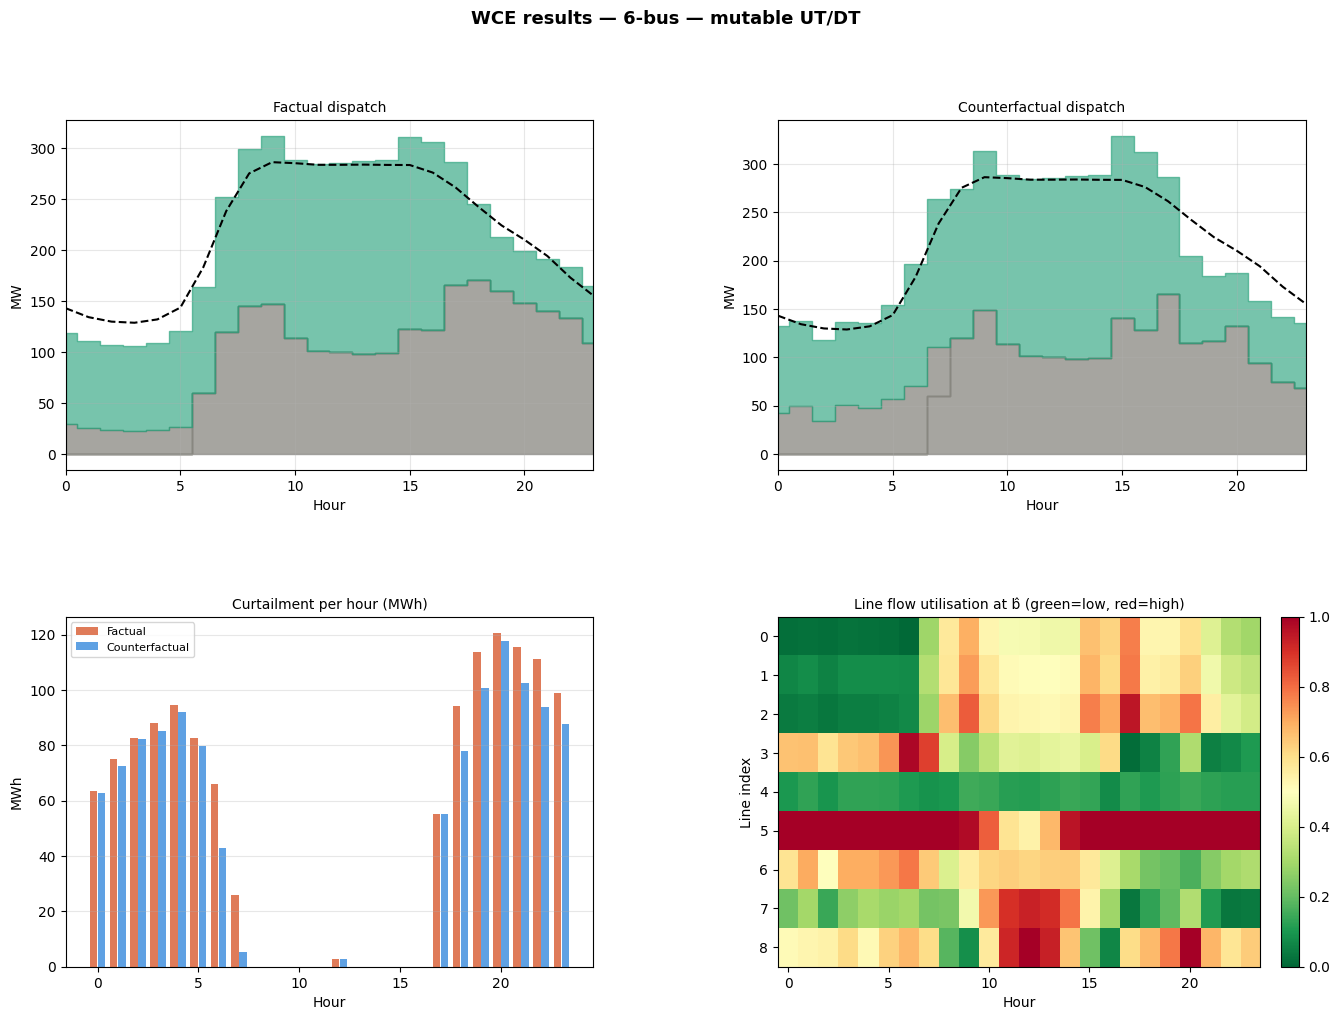

In [13]:
if res_utdt_6["success"]:
    ut_hat_6   = res_utdt_6["ut_hat"]
    dt_hat_6   = res_utdt_6["dt_hat"]
    sol_utdt_6 = res_utdt_6["sol"]
    curt_utdt_6 = float(np.sum(sol_utdt_6["curt"]))

    print(f"\n6-bus UT/DT counterfactual:")
    print(f"  Flexibility gained: {res_utdt_6['F_opt']:.1f} h  |  "
          f"gap={res_utdt_6['gap']:.2f} h  |  "
          f"nodes={res_utdt_6['nodes']}")
    print(f"  Curtailment at solution: {curt_utdt_6:.2f} MWh  (target {ct_6:.2f})")
    print(f"\n  Generator changes:")
    print(f"  {'G':>3}  {'UT_orig':>8}  {'UT_hat':>7}  {'DT_orig':>8}  {'DT_hat':>7}")
    for g in free_gens_6:
        if ut_hat_6[g] != ut_orig_6[g] or dt_hat_6[g] != dt_orig_6[g]:
            print(f"  {g:>3}  {ut_orig_6[g]:>8}  {ut_hat_6[g]:>7}  "
                  f"{dt_orig_6[g]:>8}  {dt_hat_6[g]:>7}")

    plot_wce_results(DATA_6, idx_6, sol0_6, sol_utdt_6,
                     b0_6, b0_6,
                     res_utdt_6,
                     label="6-bus — mutable UT/DT", free_idx=None)
else:
    print("No feasible UT/DT WCE found for 6-bus.")
    print(f"  nodes={res_utdt_6['nodes']}  "
          f"gap={res_utdt_6.get('gap', float('inf')):.2f} h")


### 3.2 · IEEE 14-bus — mutable UT/DT

In [14]:
free_gens_14 = get_free_generators(DATA_14.gens)
ut_orig_14   = np.array([int(g.UT) for g in DATA_14.gens])
dt_orig_14   = np.array([int(g.DT) for g in DATA_14.gens])
print(f"Free generators (14-bus): {free_gens_14}")
for g in free_gens_14:
    gen = DATA_14.gens[g]
    print(f"  G{g}: UT={gen.UT}  DT={gen.DT}  Pmax={gen.Pmax} MW  fuel=${gen.fuel_cost}/MWh")


Free generators (14-bus): [0, 1, 2, 4]
  G0: UT=6  DT=5  Pmax=332.0 MW  fuel=$34.0/MWh
  G1: UT=3  DT=2  Pmax=140.0 MW  fuel=$52.0/MWh
  G2: UT=4  DT=3  Pmax=100.0 MW  fuel=$40.0/MWh
  G4: UT=12  DT=12  Pmax=200.0 MW  fuel=$8.0/MWh


In [15]:
bs_utdt_14 = UCBranchAndSandwichUTDT(
    data=DATA_14, idx=idx_14, cvec=cvec_14,
    foil_extra_fn=make_curtailment_foil_4b(DATA_14, alpha=ALPHA, C_factual=C0_14),
    ut_orig=ut_orig_14, dt_orig=dt_orig_14,
    free_gens=free_gens_14,
    eps_obj=0.5,
    max_nodes=300,
    verbose=True,
)

res_utdt_14 = bs_utdt_14.run(
    u_init=u_init_14, p_init=p_init_14, on_t=on_t_14, off_t=off_t_14,window_size=WINDOW_SIZE, per_bus_neutrality=PER_BUS_NEUTRALITY,
)

F_utdt_14   = res_utdt_14["F_opt"]
gap_utdt_14 = (res_utdt_14["gap"] / max(abs(F_utdt_14), 1e-9) * 100
               if res_utdt_14["success"] else float("nan"))
print(f"\n14-bus UT/DT  |  F_opt={F_utdt_14:.2f}h  "
      f"|  gap={gap_utdt_14:.1f}%  |  nodes={res_utdt_14['nodes']}")

  [INC] orig: F=0.0h
  [INNER_UB] 134887105.39
[UTDT-BS] Original UT/DT satisfies foil — F=0h
  [INNER_UB] init node=0: 133740550.38
[UTDT-BS] CERTIFIED: gLB=0.00h >= bestF=0.00h

[UTDT-BS] CERTIFIED  F=0.0h  gLB=0.0h  gap=0.00h  nodes=0

14-bus UT/DT  |  F_opt=0.00h  |  gap=0.0%  |  nodes=0



14-bus UT/DT counterfactual:
  Flexibility gained: 0.0 h  |  gap=0.00 h  |  nodes=0
  Curtailment at solution: 4729.80 MWh  (target 4729.80)

  Generator changes:
    G   UT_orig   UT_hat   DT_orig   DT_hat


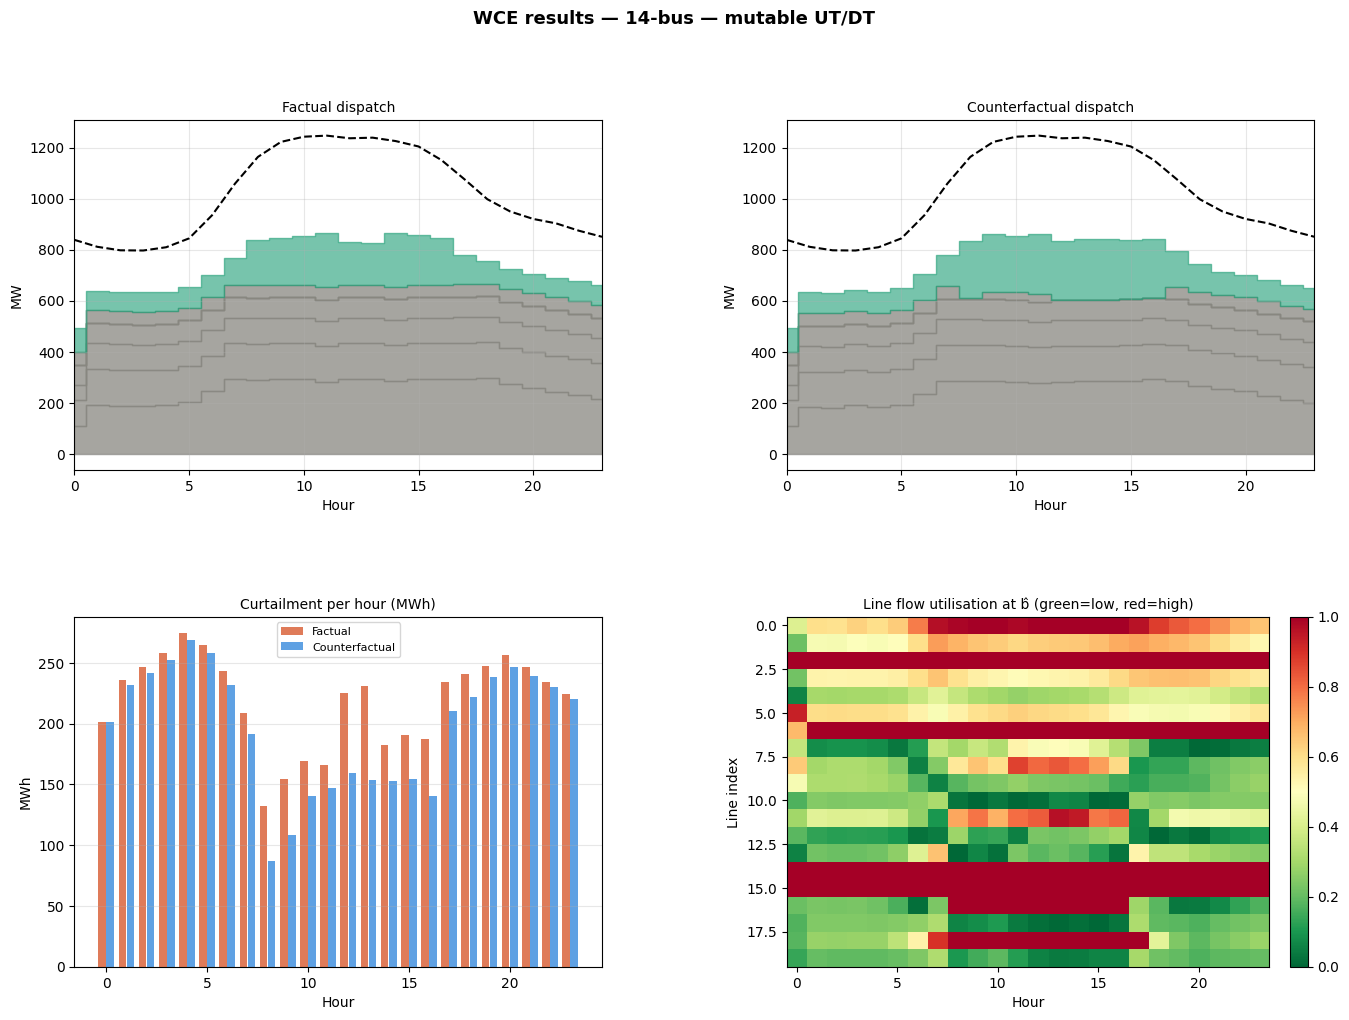

In [16]:
if res_utdt_14["success"]:
    ut_hat_14   = res_utdt_14["ut_hat"]
    dt_hat_14   = res_utdt_14["dt_hat"]
    sol_utdt_14 = res_utdt_14["sol"]
    curt_utdt_14 = float(np.sum(sol_utdt_14["curt"]))

    print(f"\n14-bus UT/DT counterfactual:")
    print(f"  Flexibility gained: {res_utdt_14['F_opt']:.1f} h  |  "
          f"gap={res_utdt_14['gap']:.2f} h  |  "
          f"nodes={res_utdt_14['nodes']}")
    print(f"  Curtailment at solution: {curt_utdt_14:.2f} MWh  (target {ct_14:.2f})")
    print(f"\n  Generator changes:")
    print(f"  {'G':>3}  {'UT_orig':>8}  {'UT_hat':>7}  {'DT_orig':>8}  {'DT_hat':>7}")
    for g in free_gens_14:
        if ut_hat_14[g] != ut_orig_14[g] or dt_hat_14[g] != dt_orig_14[g]:
            print(f"  {g:>3}  {ut_orig_14[g]:>8}  {ut_hat_14[g]:>7}  "
                  f"{dt_orig_14[g]:>8}  {dt_hat_14[g]:>7}")

    plot_wce_results(DATA_14, idx_14, sol0_14, sol_utdt_14,
                     b0_14, b0_14,
                     res_utdt_14,
                     label="14-bus — mutable UT/DT", free_idx=None)
else:
    print("No feasible UT/DT WCE found for 14-bus.")
    print(f"  nodes={res_utdt_14['nodes']}  "
          f"gap={res_utdt_14.get('gap', float('inf')):.2f} h")


### 3.3 · IEEE 39-bus — mutable UT/DT

In [17]:
free_gens_39 = get_free_generators(DATA_39.gens)
ut_orig_39   = np.array([int(g.UT) for g in DATA_39.gens])
dt_orig_39   = np.array([int(g.DT) for g in DATA_39.gens])
print(f"Free generators (39-bus): {free_gens_39}")
for g in free_gens_39:
    gen = DATA_39.gens[g]
    print(f"  G{g}: UT={gen.UT}  DT={gen.DT}  Pmax={gen.Pmax} MW  fuel=${gen.fuel_cost}/MWh")


Free generators (39-bus): [0, 1, 2, 3, 4, 5, 6, 9]
  G0: UT=24  DT=24  Pmax=1040.0 MW  fuel=$7.0/MWh
  G1: UT=8  DT=6  Pmax=500.0 MW  fuel=$32.0/MWh
  G2: UT=8  DT=6  Pmax=650.0 MW  fuel=$30.0/MWh
  G3: UT=3  DT=2  Pmax=632.0 MW  fuel=$48.0/MWh
  G4: UT=3  DT=2  Pmax=508.0 MW  fuel=$50.0/MWh
  G5: UT=3  DT=2  Pmax=650.0 MW  fuel=$46.0/MWh
  G6: UT=6  DT=5  Pmax=560.0 MW  fuel=$33.0/MWh
  G9: UT=24  DT=24  Pmax=1100.0 MW  fuel=$6.5/MWh


In [18]:
bs_utdt_39 = UCBranchAndSandwichUTDT(
    data=DATA_39, idx=idx_39, cvec=cvec_39,
    foil_extra_fn=make_curtailment_foil_4b(DATA_39, alpha=ALPHA, C_factual=C0_39),
    ut_orig=ut_orig_39, dt_orig=dt_orig_39,
    free_gens=free_gens_39,
    eps_obj=0.5,
    max_nodes=400,
    verbose=True,
)

res_utdt_39 = bs_utdt_39.run(
    u_init=u_init_39, p_init=p_init_39, on_t=on_t_39, off_t=off_t_39,window_size=WINDOW_SIZE, per_bus_neutrality=PER_BUS_NEUTRALITY,
)

F_utdt_39   = res_utdt_39["F_opt"]
gap_utdt_39 = (res_utdt_39["gap"] / max(abs(F_utdt_39), 1e-9) * 100
               if res_utdt_39["success"] else float("nan"))
print(f"\n39-bus UT/DT  |  F_opt={F_utdt_39:.2f}h  "
      f"|  gap={gap_utdt_39:.1f}%  |  nodes={res_utdt_39['nodes']}")

  [INC] orig: F=0.0h
  [INNER_UB] 2794539.20
[UTDT-BS] Original UT/DT satisfies foil — F=0h
  [INNER_UB] init node=0: 142840.59
[UTDT-BS] CERTIFIED: gLB=0.00h >= bestF=0.00h

[UTDT-BS] CERTIFIED  F=0.0h  gLB=0.0h  gap=0.00h  nodes=0

39-bus UT/DT  |  F_opt=0.00h  |  gap=0.0%  |  nodes=0



39-bus UT/DT counterfactual:
  Flexibility gained: 0.0 h  |  gap=0.00 h  |  nodes=0
  Curtailment at solution: 4270.75 MWh  (target 4270.75)

  Generator changes:
    G   UT_orig   UT_hat   DT_orig   DT_hat


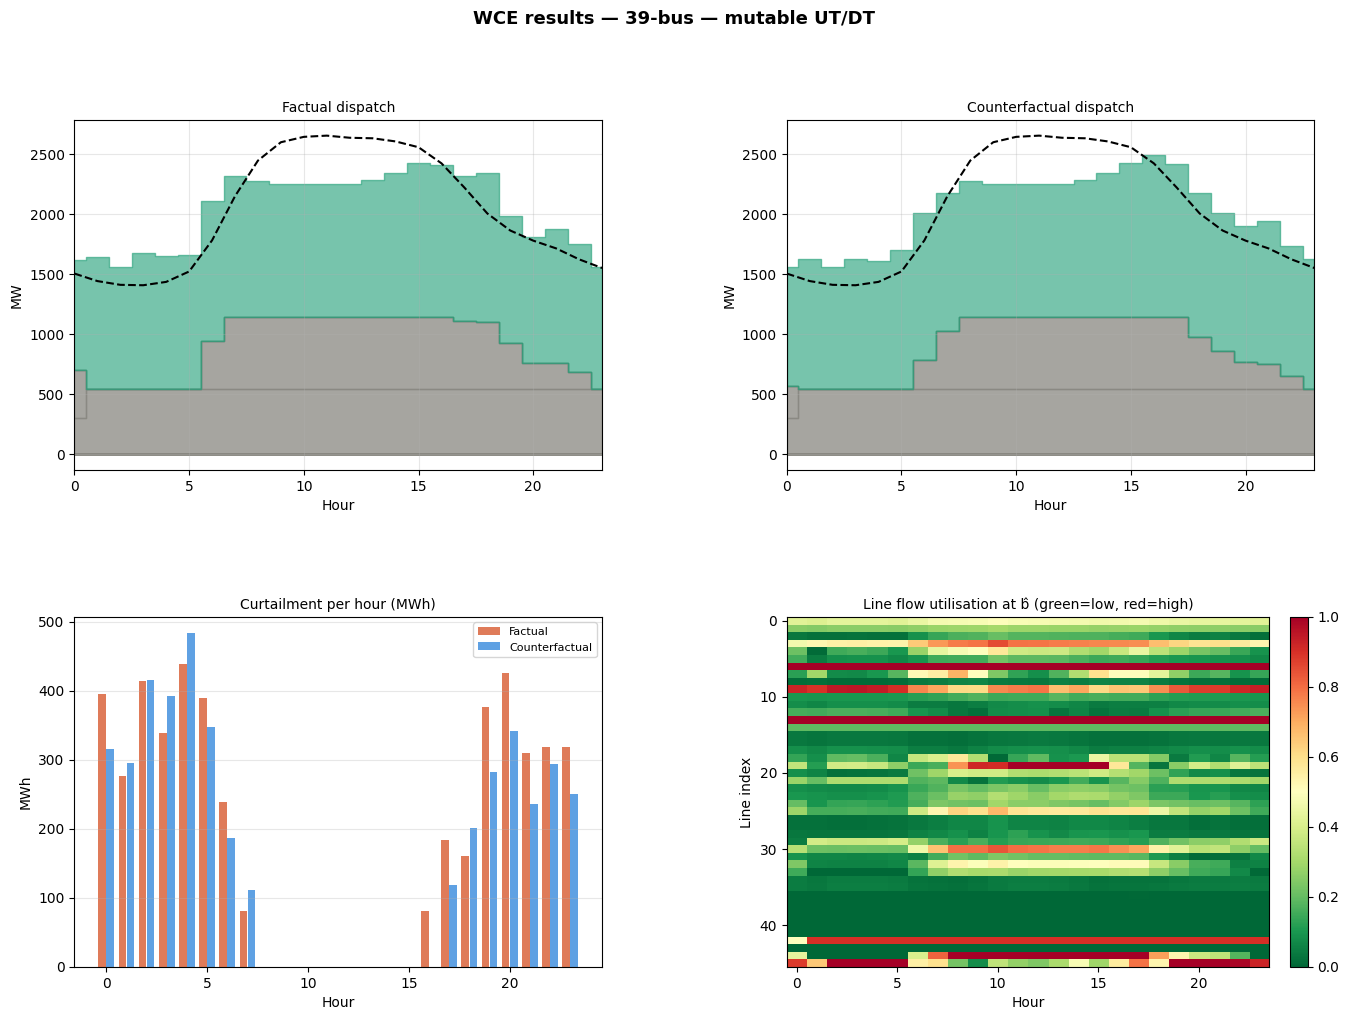

In [19]:
if res_utdt_39["success"]:
    ut_hat_39   = res_utdt_39["ut_hat"]
    dt_hat_39   = res_utdt_39["dt_hat"]
    sol_utdt_39 = res_utdt_39["sol"]
    curt_utdt_39 = float(np.sum(sol_utdt_39["curt"]))

    print(f"\n39-bus UT/DT counterfactual:")
    print(f"  Flexibility gained: {res_utdt_39['F_opt']:.1f} h  |  "
          f"gap={res_utdt_39['gap']:.2f} h  |  "
          f"nodes={res_utdt_39['nodes']}")
    print(f"  Curtailment at solution: {curt_utdt_39:.2f} MWh  (target {ct_39:.2f})")
    print(f"\n  Generator changes:")
    print(f"  {'G':>3}  {'UT_orig':>8}  {'UT_hat':>7}  {'DT_orig':>8}  {'DT_hat':>7}")
    for g in free_gens_39:
        if ut_hat_39[g] != ut_orig_39[g] or dt_hat_39[g] != dt_orig_39[g]:
            print(f"  {g:>3}  {ut_orig_39[g]:>8}  {ut_hat_39[g]:>7}  "
                  f"{dt_orig_39[g]:>8}  {dt_hat_39[g]:>7}")

    plot_wce_results(DATA_39, idx_39, sol0_39, sol_utdt_39,
                     b0_39, b0_39,
                     res_utdt_39,
                     label="39-bus — mutable UT/DT", free_idx=None)
else:
    print("No feasible UT/DT WCE found for 39-bus.")
    print(f"  nodes={res_utdt_39['nodes']}  "
          f"gap={res_utdt_39.get('gap', float('inf')):.2f} h")


### 3.4 · Cross-section comparison

In [20]:
print(f"{'Grid':<10} {'Lines F_opt':>12} {'UT/DT F_opt':>12} {'UT/DT gap%':>11} {'C_0 (MWh)':>12}")
print("-" * 62)
for lbl, res_l, res_u, C0 in [
    ("6-bus",  res_6,  res_utdt_6,  C0_6),
    ("14-bus", res_14, res_utdt_14, C0_14),
    ("39-bus", res_39, res_utdt_39, C0_39),
]:
    F_l = f"{res_l['F_opt']:.3f} MW" if res_l["success"] else "—"
    F_u = f"{res_u['F_opt']:.2f} h"  if res_u["success"] else "—"
    g_u = f"{res_u['gap']/max(abs(res_u['F_opt']),1e-9)*100:.1f}%" if res_u["success"] else "—"
    print(f"{lbl:<10} {F_l:>12} {F_u:>12} {g_u:>11} {C0:>12.2f}")


Grid        Lines F_opt  UT/DT F_opt  UT/DT gap%    C_0 (MWh)
--------------------------------------------------------------


NameError: name 'res_6' is not defined